# **Predictors of Neonatal Mortality in Pakistan: Evidence from the 2017–18 Demographic and Health Survey**

In [16]:
#PACKAGES

install.packages("tidyverse")
install.packages("survey")
install.packages("janitor")
install.packages("patchwork")
library(haven)
library(tidyverse)
library(survey)
library(janitor)
library(patchwork)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# The Data

The dataset that I am using is the 2017-18 Pakistan DHS births recode file, each observation is a birth. I selected the relevant variables that I would need for neonatal mortality and maternal +household characteristics, including: b5 b7 survival + age at death, v106 education, v190 wealth, v025 urban/rural residence, m15 place of delivery, v012 maternal age, bord birth order, b2 birth year, and the survey design variables (v005, v021, v022). I also generated a variable neonatal_death, a binary variable for if the child died within 28 days=1 and 0 if survived, and mising values were handled, since b7 is only recored for children who have died, data points with a missing b7 are not used to classify neonatal deaths and instead they were assigned missing values to avoid misclassifying. b7s missing values are structural and m15 also contains some missing values likely due to not reporting place of delivery, other variables have minimal or no missing values. The distribution of births plotted shows that most of the births happened right before the survey, which reflects DHS sampling design of capturing births within around 5 years before the survey.

b5,b7,v106,v190,v025,m15,v012,bord,b2,v005,v021,v022
<dbl+lbl>,<dbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl+lbl>
1,NA,2,1,2,11,35,5,2014,868683,1,5
1,NA,2,1,2,NA,35,4,2008,868683,1,5
1,NA,2,1,2,NA,35,3,2006,868683,1,5
1,NA,2,1,2,NA,35,2,2004,868683,1,5
1,NA,2,1,2,NA,35,1,2002,868683,1,5
1,NA,0,2,2,NA,37,5,2012,868683,1,5


b5,b7,v106,v190,v025,m15,v012,bord,b2,v005,v021,v022,neonatal_death,weight
<dbl+lbl>,<dbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl+lbl>,<dbl>,<dbl>
1,NA,2,1,2,11,35,5,2014,868683,1,5,0,0.868683
1,NA,2,1,2,NA,35,4,2008,868683,1,5,0,0.868683
1,NA,2,1,2,NA,35,3,2006,868683,1,5,0,0.868683
1,NA,2,1,2,NA,35,2,2004,868683,1,5,0,0.868683
1,NA,2,1,2,NA,35,1,2002,868683,1,5,0,0.868683
1,NA,0,2,2,NA,37,5,2012,868683,1,5,0,0.868683


[1] 50495    14

Rows: 50,495
Columns: 14
$ b5             <dbl+lbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ b7             <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ v106           <dbl+lbl> 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ v190           <dbl+lbl> 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, …
$ v025           <dbl+lbl> 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, …
$ m15            <dbl+lbl> 11, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ v012           <dbl> 35, 35, 35, 35, 35, 37, 37, 37, 37, 37, 32, 32, 32, 32,…
$ bord           <dbl> 5, 4, 3, 2, 1, 5, 4, 3, 2, 1, 5, 4, 3, 2, 1, 4, 3, 2, 1…
$ b2             <dbl> 2014, 2008, 2006, 2004, 2002, 2012, 2010, 2004, 2002, 2…
$ v005           <dbl> 868683, 868683, 868683, 868683, 868683, 868683, 868683,…
$ v021           <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ v022           <dbl+lbl> 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, …
$ neonatal_deat

b5             b7           v106           v190           v025 
    0.00000000     0.92405189     0.00000000     0.00000000     0.00000000 
           m15           v012           bord             b2           v005 
    0.74841073     0.00000000     0.00000000     0.00000000     0.00000000 
          v021           v022 neonatal_death         weight 
    0.00000000     0.00000000     0.03760768     0.00000000

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
   0.00    0.00    0.00   14.13    8.00  360.00   46660 

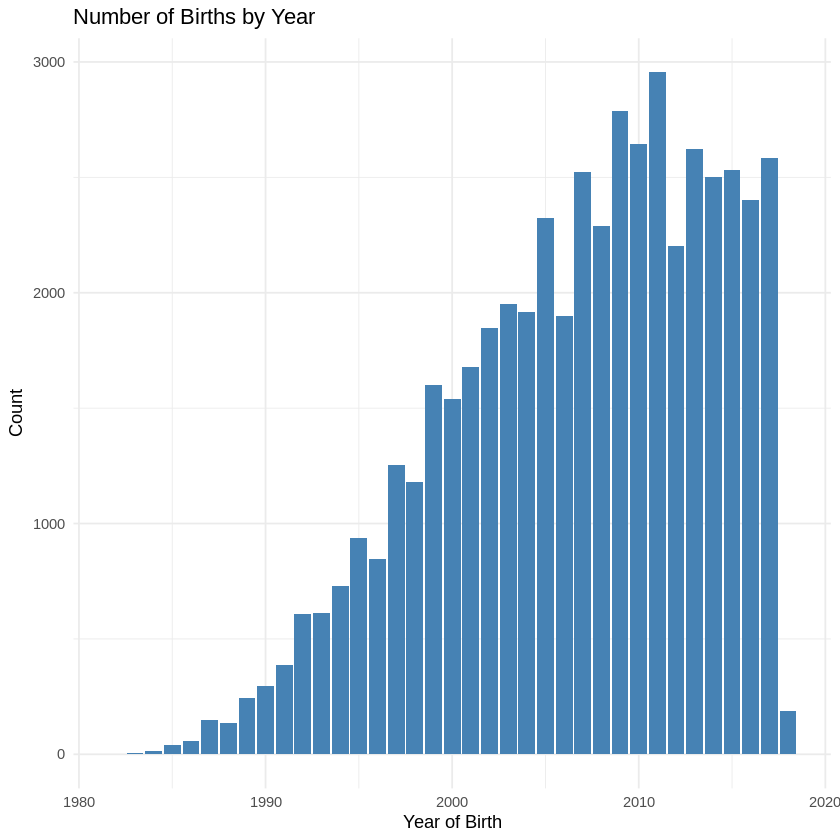

In [17]:
############################
# 1. IMPORT DATA
############################

df <- read_dta("PKBR71FL.DTA")


#keeping relevant variables
df <- df %>%
  select(
    b5, b7,#survival + age at death
    v106, #education
    v190, #wealth
    v025,#urban/rural
    m15, #place of delivery
    v012,#maternal age
    bord, #birth order
    b2, #birth year
    v005,
    v021,
    v022
  )
head(df)


df <- df %>%
  mutate(
    neonatal_death = case_when(
      b5 == 0 & !is.na(b7) & b7 <= 0 ~ 1,
      b5 == 1 ~ 0,
      TRUE ~ NA_real_
    ),
    weight = v005/ 1000000
  )

############################
# 2. SURVEY DESIGN: addresses the strata, clusters, and weighting of the DHS data
############################
design <- svydesign(
  ids = ~v021,
  strata = ~v022,
  weights = ~weight,
  data = df,
  nest = TRUE
)
head(df)


#https://dhsprogram.com/pubs/pdf/DHSG4/Recode7_DHS_10Sep2018_DHSG4.pdf

dim(df)
glimpse(df)

# df%>%count(b2)#birth years

df %>%
  count(b2) %>%
  ggplot(aes(x = b2, y = n)) +
  geom_col(fill = "steelblue") +
  labs(
    title = "Number of Births by Year",
    x = "Year of Birth",
    y = "Count"
  ) +
  theme_minimal()

colMeans(is.na(df))
summary(df$b7)

# Histograms to plot the distributions of the key variables in the analysis. Confirming that recoded missing values appropriately

Warning message:
“Removed 46660 rows containing non-finite outside the scale range
(`stat_bin()`).”


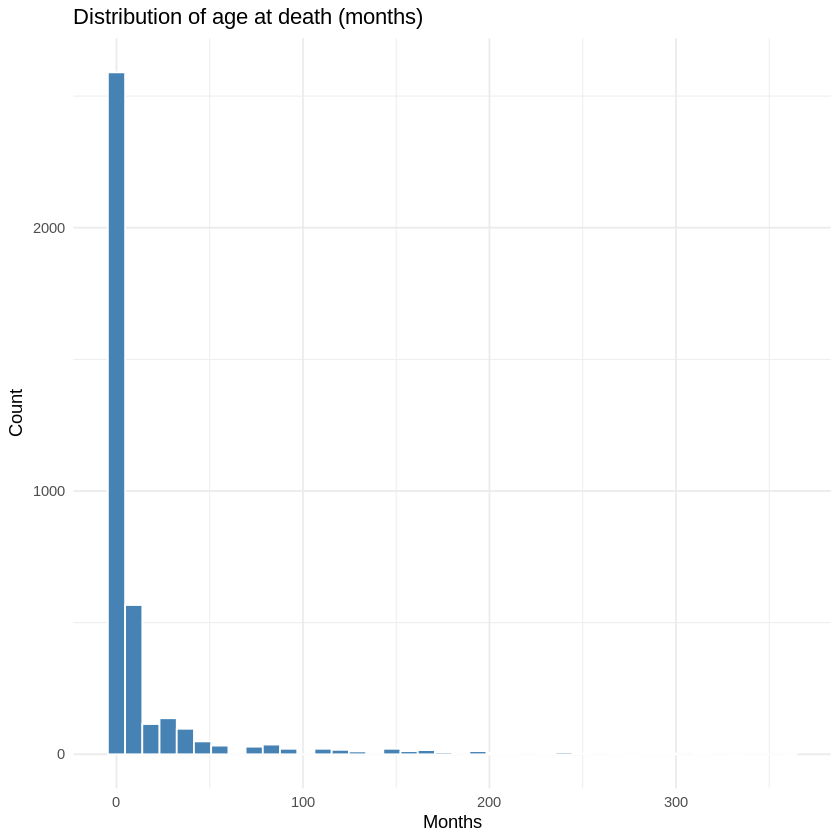

In [18]:
ggplot(df, aes(x = b7)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white") +
  labs(title = "Distribution of age at death (months)",
       x = "Months",
       y = "Count") +
  theme_minimal()


Age at death: spike within first month, no weird spikes so missing values look to be handled correctly

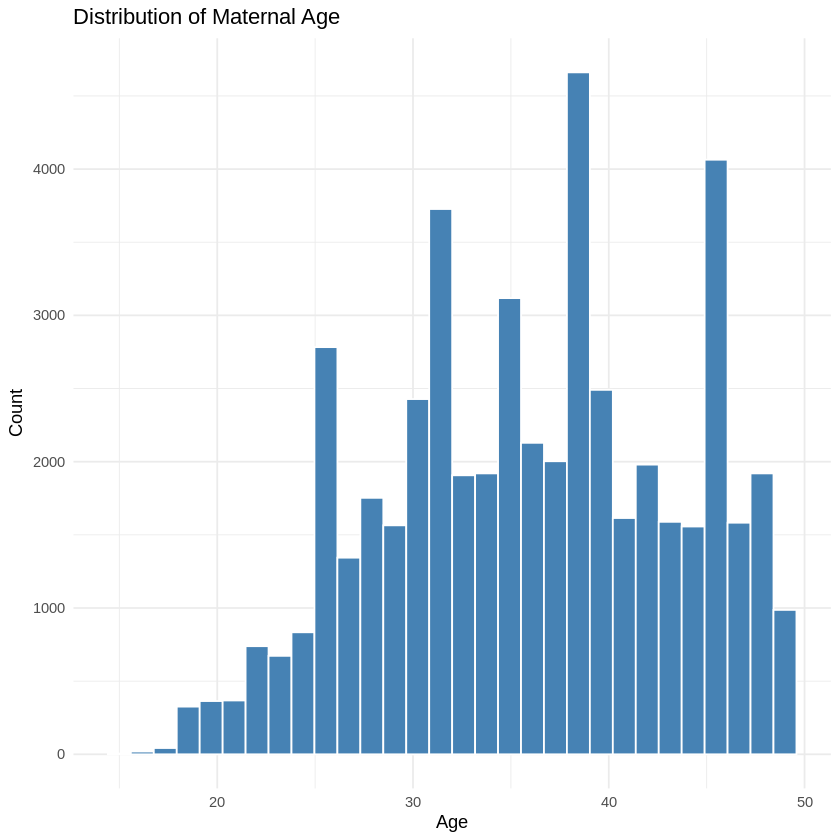

In [19]:
ggplot(df, aes(x = v012)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Maternal Age",
       x = "Age",
       y = "Count") +
  theme_minimal()


Maternal Age: v012 is the mother's current age at time of survey, not her age at each specific birth — since births span up to ~5 years before the survey, this creates a growing gap between v012 and true age-at-birth for older records. Range of ~16-50 is consistent with the DHS-eligible age window (15-49) plus this survey-age effect


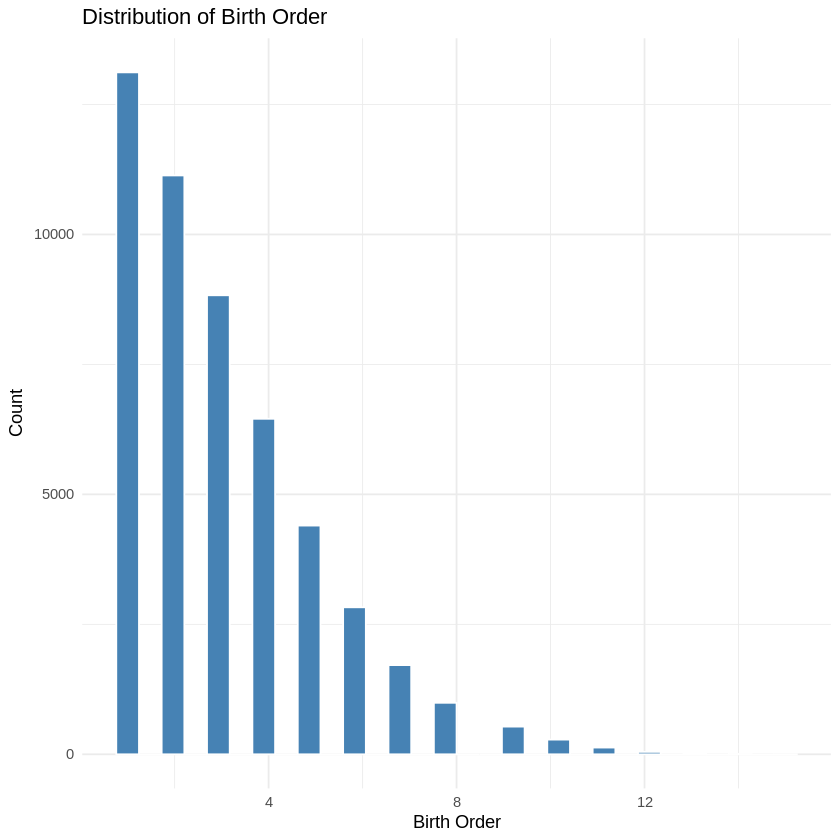

In [22]:
ggplot(df, aes(x = bord)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Birth Order",
       x = "Birth Order",
       y = "Count") +
  theme_minimal()


Birth order: looks clean, decreasing as order increases which is expected, no strange spikes



    0     1     2     3 
30697  6848  8270  4680 


    1     2     3     4     5 
11483 11803 10140  8709  8360 


   11    12    21    22    23    24    26    31    36    96  <NA> 
 4108   325  3381    65    68    21     1  4706     4    25 37791 

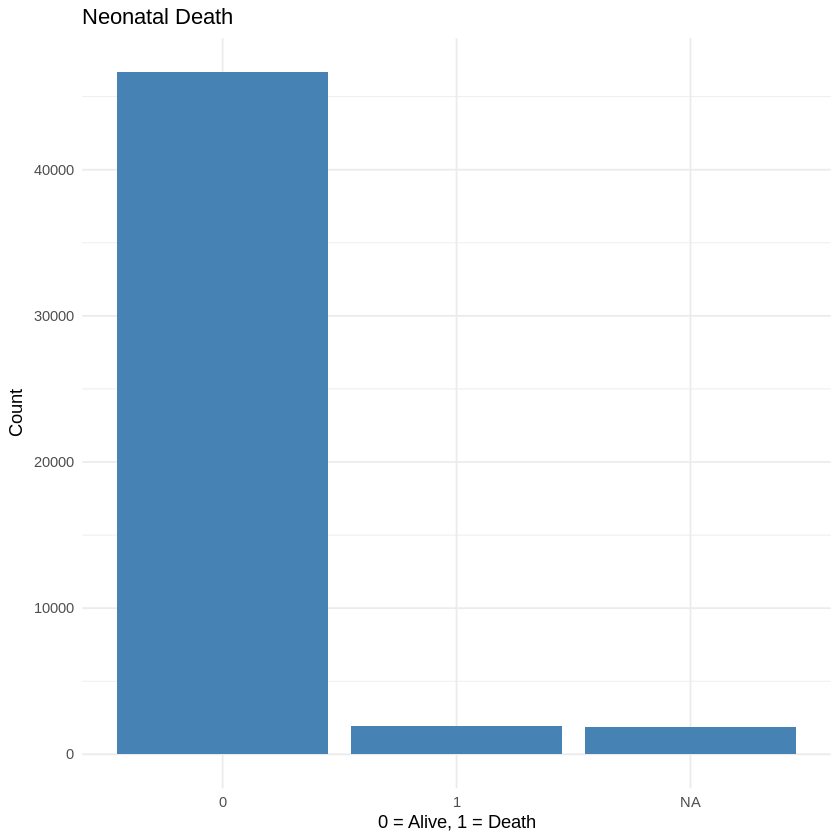

In [23]:
ggplot(df, aes(x = factor(neonatal_death))) +
  geom_bar(fill = "steelblue") +
  labs(title = "Neonatal Death",
       x = "0 = Alive, 1 = Death",
       y = "Count") +
  theme_minimal()

table(df$v106, useNA = "ifany")
table(df$v190, useNA = "ifany")
table(df$m15, useNA = "ifany")


Neonatal death: Mostly alive, few death, and some NA which is expected, missingness looks to be handled correctly

<NA>=37791 looks like a lot but these values are because age at death (b7) is only recorded for children who have died which is a structural missingness, More precise measure for maternal age at birth may be better which could be constructed

# Key predictor and outcome variables

,v106,neonatal_death,ci_l,ci_u
,<dbl+lbl>,<dbl>,<dbl>,<dbl>
0,0,0.04843384,0.04385369,0.05301398
1,1,0.04746041,0.03772598,0.05719483
2,2,0.03632599,0.02921600,0.04343597
3,3,0.02885223,0.02002551,0.03767895


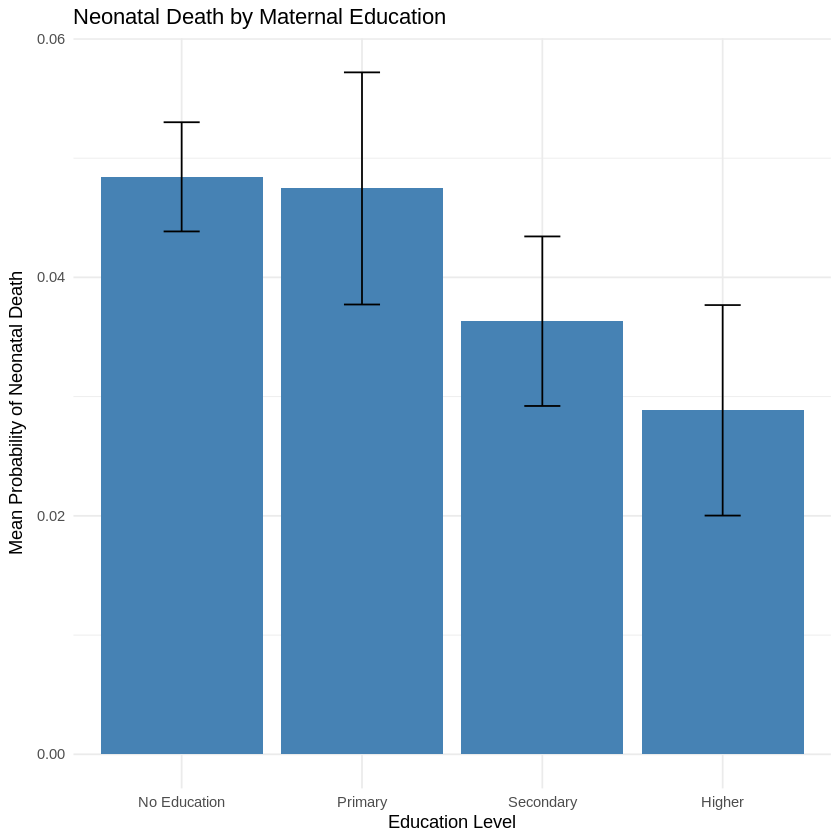

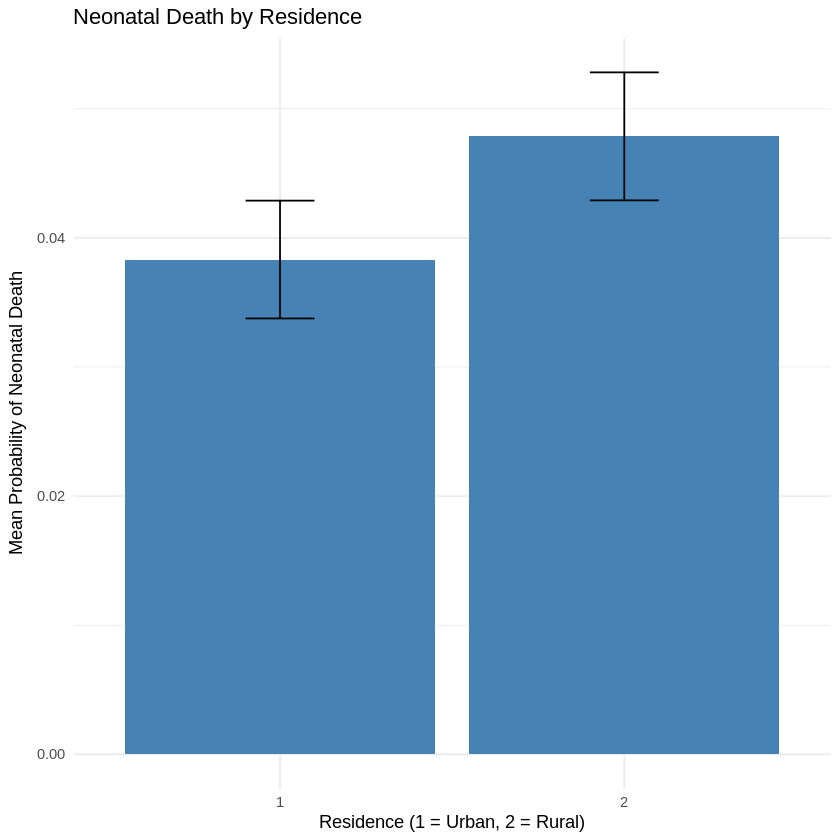

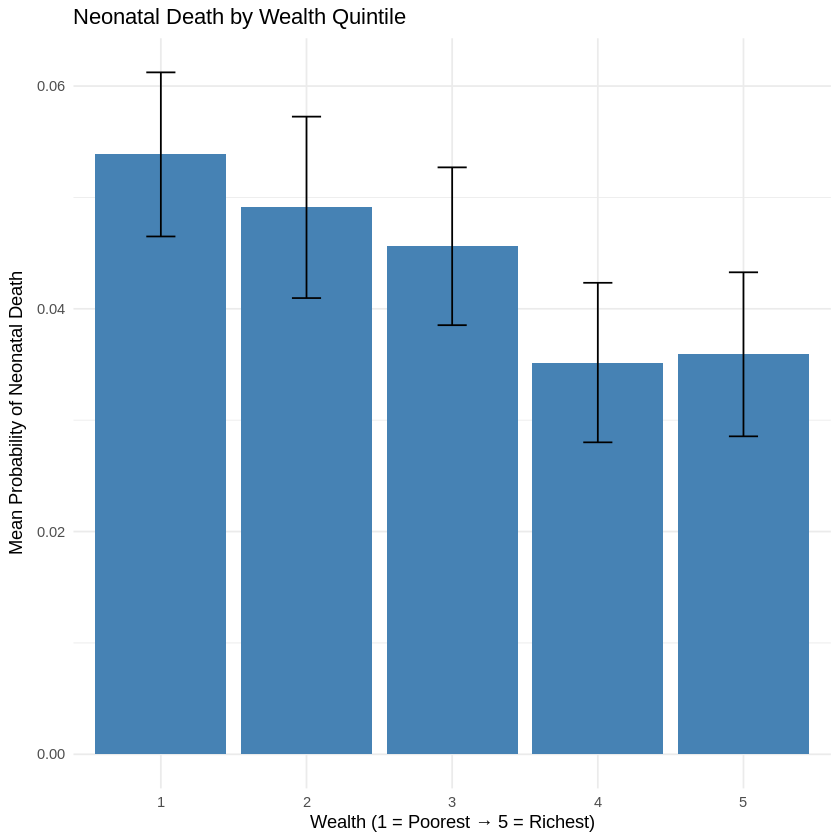

In [39]:
df <- df %>%
  mutate(
    neonatal_death = ifelse(b5 == 0 & b7 <= 0, 1, 0),
    weight = v005 / 1000000,
    b2_c = b2 - mean(b2, na.rm = TRUE)
  )

design <- svydesign(
  ids = ~v021,
  strata = ~v022,
  weights = ~weight,
  data = df,
  nest = TRUE
)

edu_plot <- svyby(
  ~neonatal_death,
  ~v106,
  design,
  svymean,
  vartype = "ci",
  na.rm = TRUE
)

edu_plot

education_plot <- ggplot(edu_plot, aes(x = factor(v106), y = neonatal_death)) +
  geom_col(fill = "steelblue") +
  geom_errorbar(aes(ymin = ci_l, ymax = ci_u), width = 0.2) +
  labs(
    title = "Neonatal Death by Maternal Education",
    x = "Education Level",
    y = "Mean Probability of Neonatal Death"
  ) +
  scale_x_discrete(labels = c("No Education", "Primary", "Secondary", "Higher")) +
  theme_minimal()
education_plot
ggsave("plots/education_plot.png", plot = education_plot, width = 6, height = 4, dpi = 300)


urban_plot <- svyby(
  ~neonatal_death,
  ~v025,
  design,
  svymean,
  vartype = "ci",
  na.rm = TRUE
)

ggplot(urban_plot, aes(x = factor(v025), y = neonatal_death)) +
  geom_col(fill = "steelblue") +
  geom_errorbar(aes(ymin = ci_l, ymax = ci_u), width = 0.2) +
  labs(
    title = "Neonatal Death by Residence",
    x = "Residence (1 = Urban, 2 = Rural)",
    y = "Mean Probability of Neonatal Death"
  ) +
  theme_minimal()

wealth_plot <- svyby(
  ~neonatal_death,
  ~v190,
  design,
  svymean,
  vartype = "ci",
  na.rm = TRUE
)

wealth_plot <- ggplot(wealth_plot, aes(x = factor(v190), y = neonatal_death)) +
  geom_col(fill = "steelblue") +
  geom_errorbar(aes(ymin = ci_l, ymax = ci_u), width = 0.2) +
  labs(
    title = "Neonatal Death by Wealth Quintile",
    x = "Wealth (1 = Poorest → 5 = Richest)",
    y = "Mean Probability of Neonatal Death"
  ) +
  theme_minimal()
wealth_plot
ggsave("plots/wealth_plot.png", plot = wealth_plot, width = 6, height = 4, dpi = 300)

These plots show very strong patterns accross education, wealth and the rural/urban residence. These relationshops are consistent with overall findings around the world and the data is very clear.

# Descriptive Table 1 displaying the mean and standard deviation of each of the variables

In [26]:
library(dplyr)

table1 <- df %>%
  summarise(
    neonatal_death_mean = mean(neonatal_death, na.rm = TRUE),
    neonatal_death_sd   = sd(neonatal_death, na.rm = TRUE),

    maternal_age_mean = mean(v012, na.rm = TRUE),
    maternal_age_sd   = sd(v012, na.rm = TRUE),

    birth_order_mean = mean(bord, na.rm = TRUE),
    birth_order_sd   = sd(bord, na.rm = TRUE)
  )

table1

table(df$v106)
table(df$v190)
table(df$v025)

nrow(df)

neonatal_death_mean,neonatal_death_sd,maternal_age_mean,maternal_age_sd,birth_order_mean,birth_order_sd
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.03834043,0.1920187,36.01866,7.486387,3.101733,2.054793



    0     1     2     3 
30697  6848  8270  4680 


    1     2     3     4     5 
11483 11803 10140  8709  8360 


    1     2 
23059 27436 

[1] 50495

# Preliminary Data Analysis


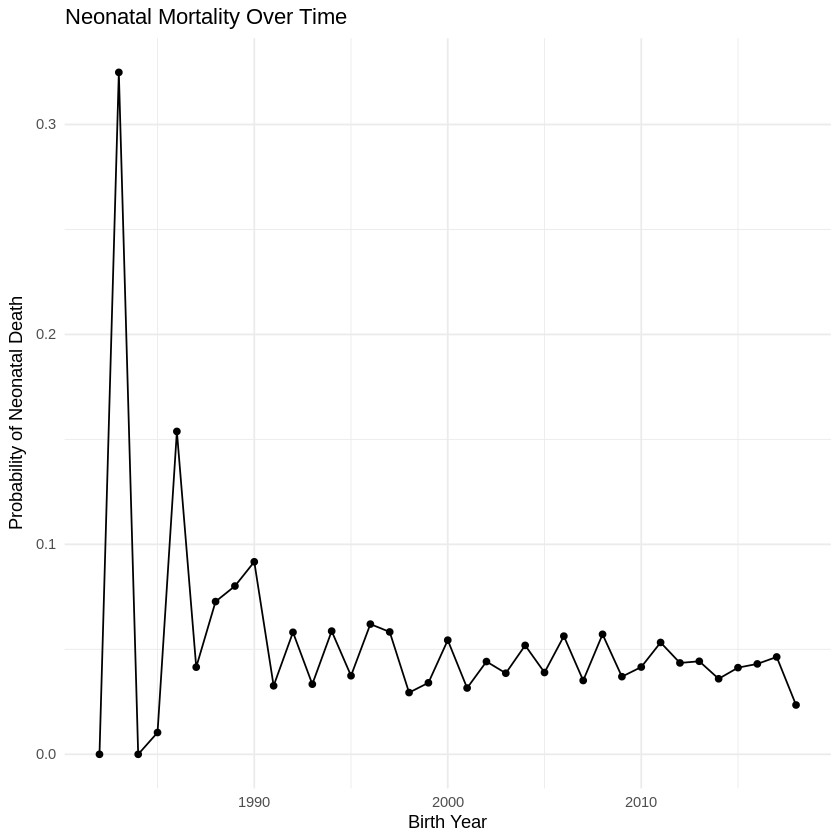

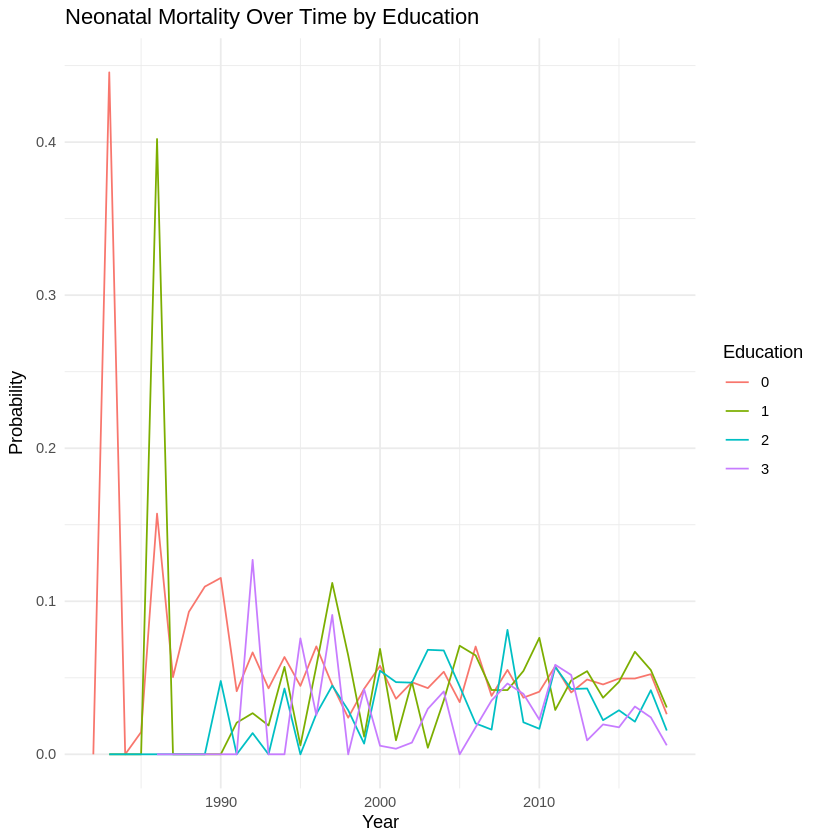

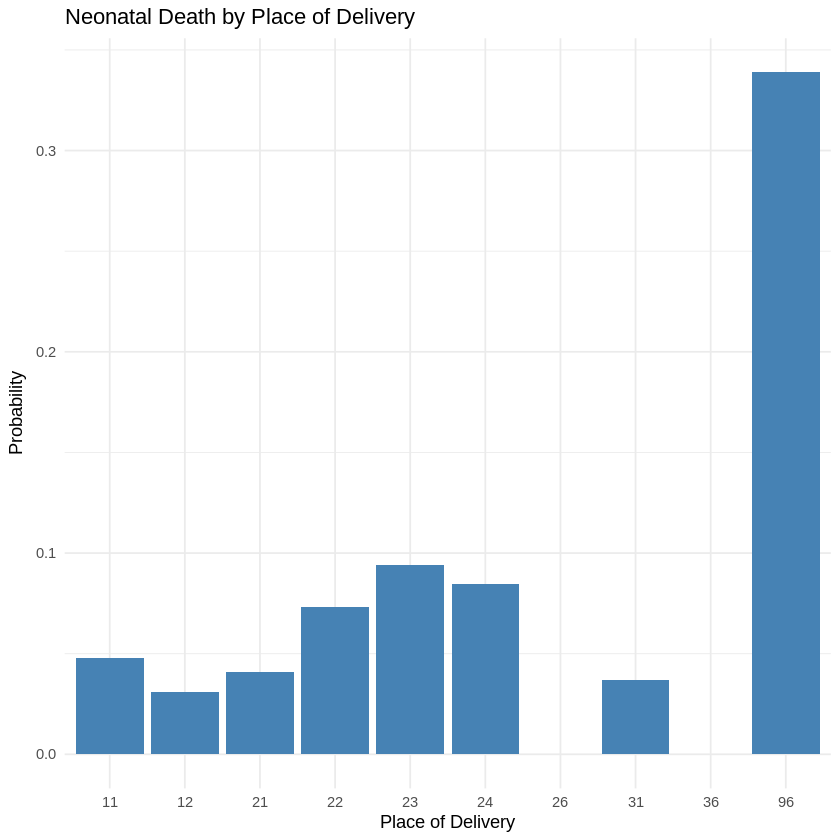

In [27]:
time_results <- svyby(
  ~neonatal_death,
  ~b2,
  design,
  svymean,
  na.rm = TRUE
)

ggplot(time_results, aes(x = b2, y = neonatal_death)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Neonatal Mortality Over Time",
    x = "Birth Year",
    y = "Probability of Neonatal Death"
  ) +
  theme_minimal()

svyby(~neonatal_death, ~b2 + v106, design, svymean, na.rm = TRUE) %>%
  ggplot(aes(x = b2, y = neonatal_death, color = factor(v106))) +
  geom_line() +
  labs(
    title = "Neonatal Mortality Over Time by Education",
    x = "Year",
    y = "Probability",
    color = "Education"
  ) +
  theme_minimal()


delivery_results <- svyby(
  ~neonatal_death,
  ~m15,
  design,
  svymean,
  na.rm = TRUE
)

ggplot(delivery_results, aes(x = factor(m15), y = neonatal_death)) +
  geom_col(fill = "steelblue") +
  labs(
    title = "Neonatal Death by Place of Delivery",
    x = "Place of Delivery",
    y = "Probability"
  ) +
  theme_minimal()

In [29]:
df <- df %>%
  mutate(
    delivery_type = case_when(
      m15 %in% c(10,11,12) ~ "Home",
      m15 %in% c(20,21,22,23,24,26,30,31,36) ~ "Facility",
      TRUE ~ NA_character_
    )
  )

design <- update(design, delivery_type = df$delivery_type)
design <- update(design, b2_c = df$b2_c)

#update survey design
model <- svyglm(
  neonatal_death ~ factor(v106) + factor(v190) + factor(v025) +
    factor(delivery_type) + v012 + bord + b2_c,
  design = design,
  family = quasibinomial()
)

summary(model)

or_table <- cbind(
  OR = exp(coef(model)),
  exp(confint(model))
)
or_table


Warning message in summary.glm(g):
“observations with zero weight not used for calculating dispersion”
Warning message in summary.glm(glm.object):
“observations with zero weight not used for calculating dispersion”



Call:
svyglm(formula = neonatal_death ~ factor(v106) + factor(v190) + 
    factor(v025) + factor(delivery_type) + v012 + bord + b2_c, 
    design = design, family = quasibinomial())

Survey design:
update(design, b2_c = df$b2_c)

Coefficients:
                            Estimate Std. Error t value Pr(>|t|)   
(Intercept)               -1.4102867  0.8053209  -1.751  0.08062 . 
factor(v106)1             -0.0109370  0.2091508  -0.052  0.95832   
factor(v106)2             -0.5247003  0.2451646  -2.140  0.03290 * 
factor(v106)3             -0.8773039  0.3049815  -2.877  0.00422 **
factor(v190)2              0.0930837  0.2075329   0.449  0.65400   
factor(v190)3             -0.0644055  0.2162624  -0.298  0.76599   
factor(v190)4             -0.0309586  0.2588965  -0.120  0.90487   
factor(v190)5              0.3544266  0.3503918   1.012  0.31233   
factor(v025)2              0.0140219  0.2033814   0.069  0.94507   
factor(delivery_type)Home  0.0005892  0.1517989   0.004  0.99690   
v012   

,OR,2.5 %,97.5 %
(Intercept),0.2440733,0.05013176,1.1883042
factor(v106)1,0.9891225,0.65572652,1.4920297
factor(v106)2,0.5917327,0.36547487,0.9580619
factor(v106)3,0.4159027,0.22838365,0.7573881
factor(v190)2,1.0975536,0.72992697,1.6503348
factor(v190)3,0.9376247,0.61295884,1.4342562
factor(v190)4,0.9695157,0.58286160,1.6126653
factor(v190)5,1.4253631,0.71587528,2.8380081
factor(v025)2,1.0141207,0.67996557,1.5124894
factor(delivery_type)Home,1.0005894,0.74247711,1.3484309


Preliminary analysis shows that neonatal mortality is higher among mothers with less education, poorer households, and rural. Mortality declines over time, but earlier years are noisy because there are fewer births in those years. In the regression model adjusting for the other factors, maternal education is the strongest predictor, Maternal age is also significant, older mothers assiciated with lower mortality. Wealth, urban/rural residence, delivery type, and birth year do not appear to be statistically significant, suggesting that their effects might be explained with other correlated factors, birth order also shows a weak association. The analysis is observational, so they cannot be interpreted causally

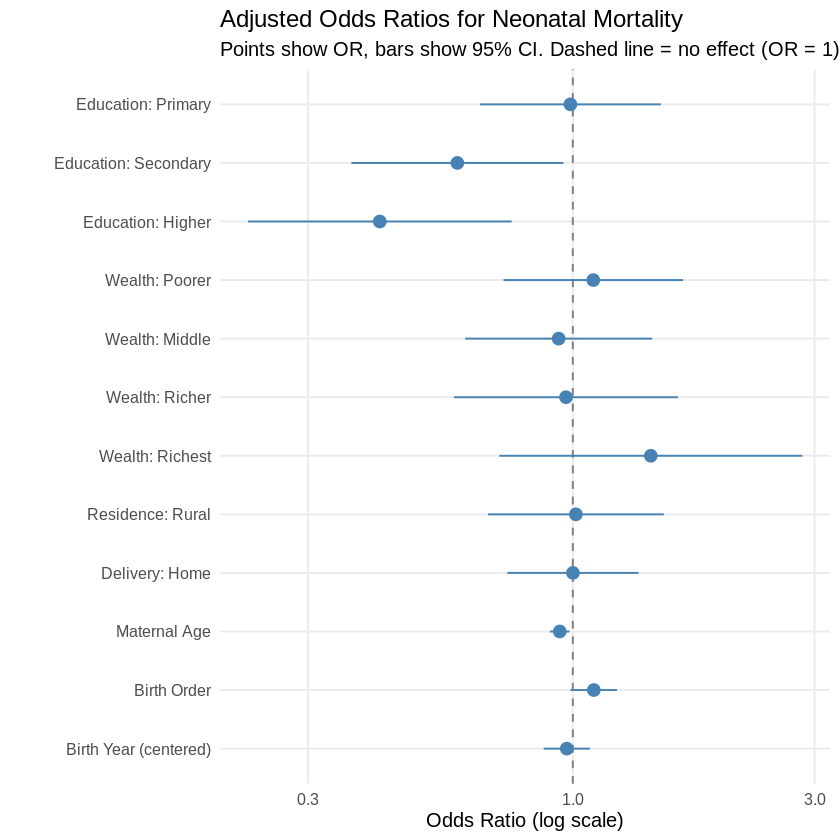

In [40]:
#Forest PLot
#Convert or_table (matrix) into a tidy data frame
forest_df <- as.data.frame(or_table) %>%
  rownames_to_column("term") %>%
  rename(OR = OR, lower = `2.5 %`, upper = `97.5 %`) %>%
  filter(term != "(Intercept)")  #intercept isn't meaningful to plot alongside covariates

#Clean up variable names for readability
forest_df <- forest_df %>%
  mutate(term = recode(term,
    "factor(v106)1" = "Education: Primary",
    "factor(v106)2" = "Education: Secondary",
    "factor(v106)3" = "Education: Higher",
    "factor(v190)2" = "Wealth: Poorer",
    "factor(v190)3" = "Wealth: Middle",
    "factor(v190)4" = "Wealth: Richer",
    "factor(v190)5" = "Wealth: Richest",
    "factor(v025)2" = "Residence: Rural",
    "factor(delivery_type)Home" = "Delivery: Home",
    "v012" = "Maternal Age",
    "bord" = "Birth Order",
    "b2_c" = "Birth Year (centered)"
  ))

#order factor levels
forest_df$term <- factor(forest_df$term, levels = rev(forest_df$term))

ggplot(forest_df, aes(x = OR, y = term)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey50") +
  geom_pointrange(aes(xmin = lower, xmax = upper), color = "steelblue", size = 0.6) +
  scale_x_log10() +  #log scale
  labs(
    title = "Adjusted Odds Ratios for Neonatal Mortality",
    subtitle = "Points show OR, bars show 95% CI. Dashed line = no effect (OR = 1)",
    x = "Odds Ratio (log scale)",
    y = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

ggsave("plots/forest_plot.png", width = 9, height = 5, dpi = 300)